# Log Anomaly Detection System

**Author:** [Tanika Vashisht]  
**Institution:** [Bennett University]  
**Date:** April 2026

---

### Project Overview
A hybrid log anomaly detection pipeline combining **Isolation Forest** for point anomaly detection and a **CNN-LSTM** deep learning model for sequence anomaly detection on structured HDFS logs.

| Stage | Tool/Method |
|---|---|
| Log Parsing | Drain Parser |
| Point Anomaly | Isolation Forest |
| Sequence Anomaly | CNN + LSTM |
| Final Detection | Hybrid Fusion (OR logic) |

# Log Anomaly Detection System

A hybrid approach combining **Isolation Forest** (point anomaly detection) with a **CNN-LSTM** deep learning model (sequence anomaly detection) on structured HDFS logs.

## Step 1 — Environment Setup

In [3]:
!git clone https://github.com/logpai/logparser.git
!pip install scikit-learn pandas matplotlib tensorflow --quiet

Cloning into 'logparser'...
remote: Enumerating objects: 3201, done.
remote: Counting objects: 100% (401/401), done.
remote: Compressing objects: 100% (218/218), done.
remote: Total 3201 (delta 232), reused 183 (delta 183), pack-reused 2800 (from 2)
Receiving objects: 100% (3201/3201), 264.33 MiB | 16.47 MiB/s, done.
Resolving deltas: 100% (1248/1248), done.
Updating files: 100% (392/392), done.


## Step 2 — Upload Log File

In [6]:
from google.colab import files
uploaded = files.upload()

Saving HDFS_2k.log to HDFS_2k (1).log


## Step 3 — Parse Unstructured Logs 

In [10]:
import sys, os
sys.path.append('/content/logparser/logparser/Drain') # Corrected path to the Drain module directory
from Drain import LogParser

input_dir  = './'
output_dir = './Drain_result/'
log_file   = 'HDFS_2k.log'

os.makedirs(output_dir, exist_ok=True)

log_format = '<Date> <Time> <Pid> <Level> <Component>: <Content>'
parser = LogParser(log_format=log_format, indir=input_dir, outdir=output_dir, depth=4, st=0.5)
parser.parse(log_file)

/content/logparser/logparser/Drain/Drain.py:353: SyntaxWarning: invalid escape sequence '\s'
  splitter = re.sub(" +", "\\\s+", splitters[k])
/content/logparser/logparser/Drain/Drain.py:368: SyntaxWarning: invalid escape sequence '\<'
  template_regex = "^" + template_regex.replace("\<\*\>", "(.*?)") + "$"


Parsing file: ./HDFS_2k.log
Total lines:  2000
Processed 50.0% of log lines.
Processed 100.0% of log lines.
Parsing done. [Time taken: 0:00:00.352448]


## Step 4 — Load Structured Logs

In [11]:
import pandas as pd

structured_log = pd.read_csv('./Drain_result/HDFS_2k.log_structured.csv')
structured_log.head()

,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate,ParameterList
0,1,81109,203615,148,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...,dc2c74b7,PacketResponder <*> for block <*> terminating,"['1', 'blk_38865049064139660']"
1,2,81109,203807,222,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...,dc2c74b7,PacketResponder <*> for block <*> terminating,"['0', 'blk_-6952295868487656571']"
2,3,81109,204005,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,5d5de21c,BLOCK* NameSystem.addStoredBlock: blockMap upd...,"['10.251.73.220:50010', 'blk_71283702376877284..."
3,4,81109,204015,308,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_82291938032499...,dc2c74b7,PacketResponder <*> for block <*> terminating,"['2', 'blk_8229193803249955061']"
4,5,81109,204106,329,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368...,dc2c74b7,PacketResponder <*> for block <*> terminating,"['2', 'blk_-6670958622368987959']"


## Step 5 — Feature Engineering

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
structured_log['EventId_encoded'] = le.fit_transform(structured_log['EventId'])

event_counts = structured_log['EventId'].value_counts().to_dict()
structured_log['Event_Frequency'] = structured_log['EventId'].map(event_counts)

X = structured_log[['EventId_encoded', 'Event_Frequency']]
structured_log.head()

,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate,ParameterList,EventId_encoded,Event_Frequency
0,1,81109,203615,148,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...,dc2c74b7,PacketResponder <*> for block <*> terminating,"['1', 'blk_38865049064139660']",14,311
1,2,81109,203807,222,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...,dc2c74b7,PacketResponder <*> for block <*> terminating,"['0', 'blk_-6952295868487656571']",14,311
2,3,81109,204005,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,5d5de21c,BLOCK* NameSystem.addStoredBlock: blockMap upd...,"['10.251.73.220:50010', 'blk_71283702376877284...",9,314
3,4,81109,204015,308,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_82291938032499...,dc2c74b7,PacketResponder <*> for block <*> terminating,"['2', 'blk_8229193803249955061']",14,311
4,5,81109,204106,329,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368...,dc2c74b7,PacketResponder <*> for block <*> terminating,"['2', 'blk_-6670958622368987959']",14,311


## Step 6 — Model 1: Isolation Forest 

In [13]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(n_estimators=200, contamination=0.02, max_samples='auto', random_state=42)
iso_model.fit(X)

structured_log['Anomaly'] = iso_model.predict(X)
structured_log['Anomaly'] = structured_log['Anomaly'].map({1: 0, -1: 1})
structured_log['Anomaly'].value_counts()

,count
Anomaly,
0,1971
1,29


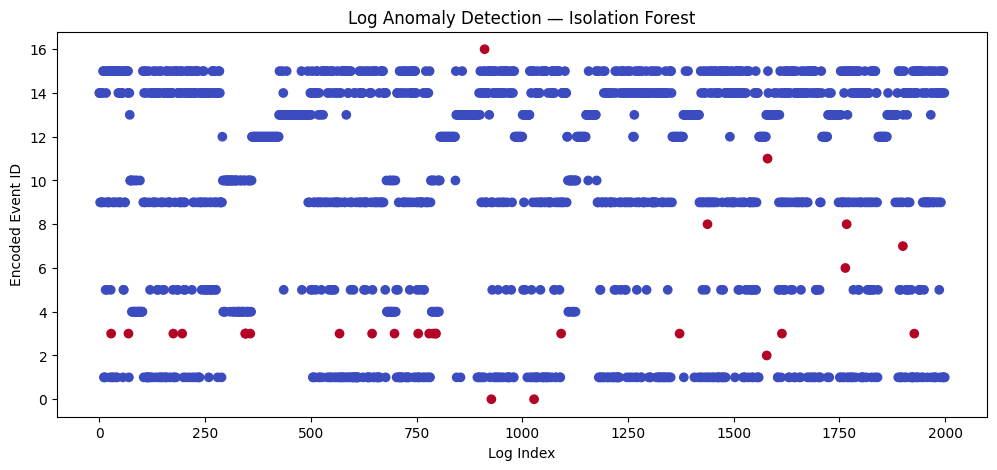

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.scatter(range(len(structured_log)), structured_log['EventId_encoded'],
            c=structured_log['Anomaly'], cmap='coolwarm')
plt.title("Log Anomaly Detection — Isolation Forest")
plt.xlabel("Log Index")
plt.ylabel("Encoded Event ID")
plt.show()

## Step 7 — Sliding Window Sequences 

In [15]:
import numpy as np

sequence_length = 10
sequences, labels_seq = [], []

for i in range(len(structured_log) - sequence_length):
    sequences.append(structured_log['EventId_encoded'].values[i:i + sequence_length])
    labels_seq.append(structured_log['EventId_encoded'].values[i + sequence_length])

sequences  = np.array(sequences)
labels_seq = np.array(labels_seq)

## Step 8 — Model 2: CNN-LSTM

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=len(le.classes_), output_dim=64, input_length=sequence_length),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [20]:
history = model.fit(sequences, labels_seq, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.1972 - loss: 2.5048 - val_accuracy: 0.2814 - val_loss: 1.8585
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3970 - loss: 1.6966 - val_accuracy: 0.3568 - val_loss: 1.6361
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4014 - loss: 1.5075 - val_accuracy: 0.3216 - val_loss: 1.6058
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4001 - loss: 1.4612 - val_accuracy: 0.3643 - val_loss: 1.5784
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4127 - loss: 1.4187 - val_accuracy: 0.3442 - val_loss: 1.5689


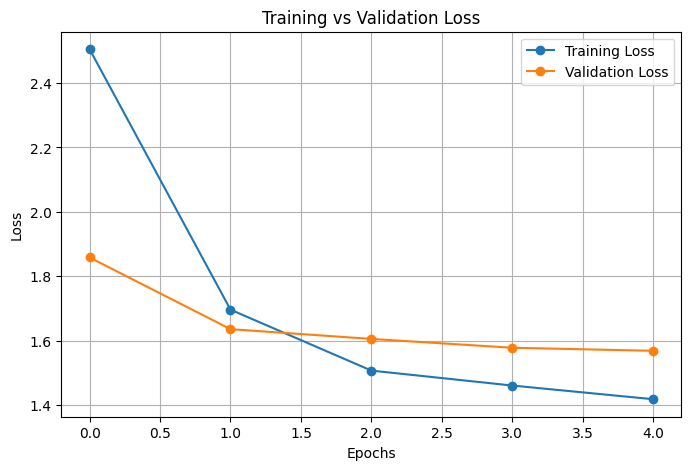

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Step 9 — CNN-LSTM Anomaly Detection 

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


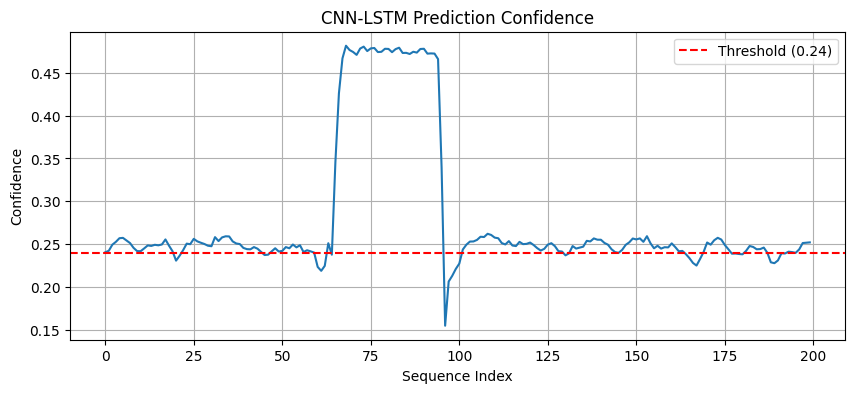

In [22]:
predictions = model.predict(sequences)
confidence  = np.max(predictions, axis=1)

threshold     = np.percentile(confidence, 10)
anomaly_lstm  = (confidence < threshold).astype(int)

plt.figure(figsize=(10, 4))
plt.plot(confidence[:200])
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.2f})')
plt.title("CNN-LSTM Prediction Confidence")
plt.xlabel("Sequence Index")
plt.ylabel("Confidence")
plt.legend()
plt.grid(True)
plt.show()

## Step 10 — Hybrid Model: Isolation Forest + CNN-LSTM

In [23]:
iso_preds    = structured_log['Anomaly'].values[:len(anomaly_lstm)]
final_anomaly = ((iso_preds == 1) | (anomaly_lstm == 1)).astype(int)

print("Isolation Forest anomalies :", np.sum(iso_preds))
print("CNN-LSTM anomalies         :", np.sum(anomaly_lstm))
print("Final hybrid anomalies     :", np.sum(final_anomaly))

Isolation Forest anomalies : 29
CNN-LSTM anomalies         : 199
Final hybrid anomalies     : 224


## Step 11 — Final Hybrid Anomaly Detection Visualization

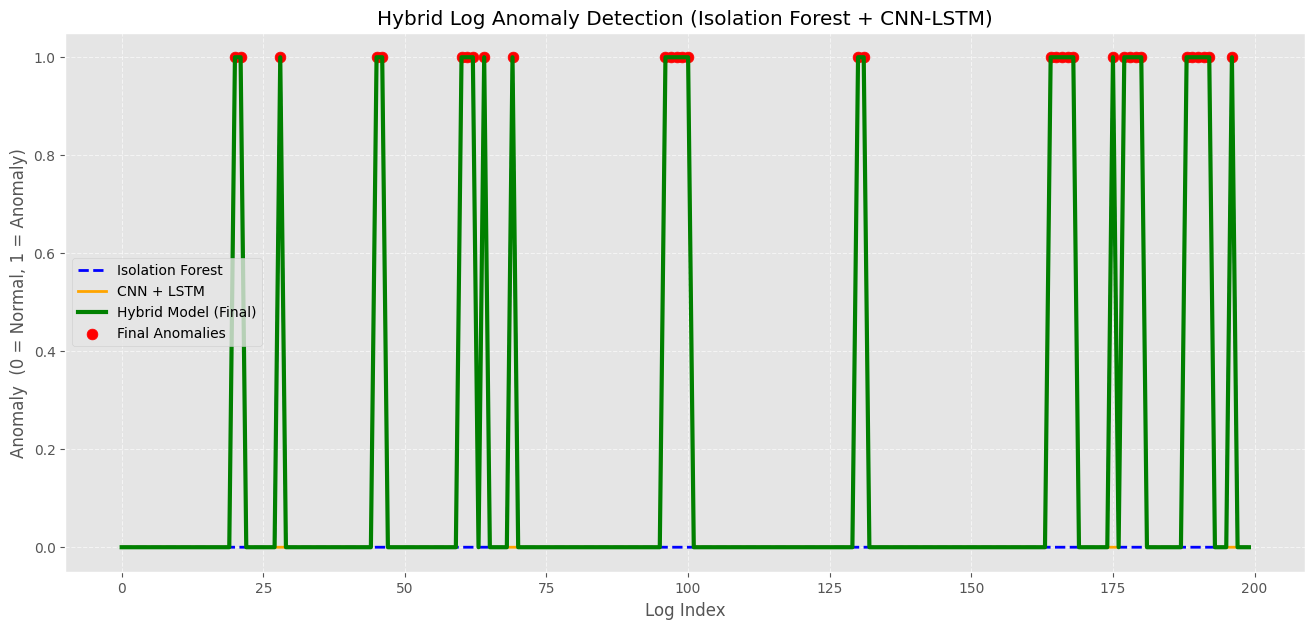

In [24]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

n = 200
x = np.arange(n)

plt.figure(figsize=(16, 7))

plt.plot(x, iso_preds[:n],     color='blue',  linestyle='--', linewidth=2, label="Isolation Forest")
plt.plot(x, anomaly_lstm[:n],  color='orange', linestyle='-',  linewidth=2, label="CNN + LSTM")
plt.plot(x, final_anomaly[:n], color='green',  linewidth=3,                label="Hybrid Model (Final)")

anomaly_idx = np.where(final_anomaly[:n] == 1)
plt.scatter(anomaly_idx, final_anomaly[:n][anomaly_idx], color='red', s=60, label="Final Anomalies")

plt.title("Hybrid Log Anomaly Detection (Isolation Forest + CNN-LSTM)")
plt.xlabel("Log Index")
plt.ylabel("Anomaly  (0 = Normal, 1 = Anomaly)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()